Step 1: Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load the dataset
# Replace 'Pt_all_properties.csv' with your actual file path if it's in a different folder
df = pd.read_csv('get-descriptors-all.csv')

print(f"Initial dataset shape: {df.shape}")
display(df)


Initial dataset shape: (19, 410)


,Compound_Name,Activity,HOMO_Boltz,HOMO_Boltz_stdev,HOMO_min,HOMO_max,HOMO_range,HOMO_low_E,LUMO_Boltz,LUMO_Boltz_stdev,...,Hirsh_CM5_charge_N2_min,Hirsh_CM5_charge_N2_max,Hirsh_CM5_charge_N2_range,Hirsh_CM5_charge_N2_low_E,Hirsh_atom_dipole_N2_Boltz,Hirsh_atom_dipole_N2_Boltz_stdev,Hirsh_atom_dipole_N2_min,Hirsh_atom_dipole_N2_max,Hirsh_atom_dipole_N2_range,Hirsh_atom_dipole_N2_low_E
0,CHEMBL1743583,0,-0.52242,-0.541884,2.119619e-03,-0.54203,-0.52242,0.01961,-0.36502,-0.356649,...,0.001007,-0.576080,-0.566774,0.009306,0.573028,0.583406,0.001133,0.573028,0.583501,0.010473
1,CHEMBL1743593,0,-0.53536,-0.535313,7.785028e-05,-0.53633,-0.53530,0.00103,-0.32763,-0.326923,...,0.000071,-0.577076,-0.575784,0.001292,0.582518,0.583083,0.000058,0.582383,0.583480,0.001097
2,CHEMBL1743594,0,-0.49572,-0.490840,2.802763e-03,-0.49572,-0.47980,0.01592,-0.33121,-0.328680,...,0.002143,-0.588606,-0.568919,0.019687,0.582573,0.582210,0.002051,0.574566,0.594035,0.019469
3,CHEMBL2068442,0,-0.21667,-0.216606,9.138974e-05,-0.21667,-0.21650,0.00017,-0.04200,-0.042038,...,0.000100,-0.594186,-0.594026,0.000160,0.599968,0.599857,0.000147,0.599712,0.599968,0.000256
4,CHEMBL611190,0,-0.36499,-0.363982,8.831147e-04,-0.36628,-0.36289,0.00339,-0.18197,-0.181061,...,0.101285,-0.589790,-0.307179,0.282611,0.592669,0.554486,0.103360,0.307395,0.596087,0.288693
5,carboplatin,1,-0.22374,-0.223735,7.071043e-06,-0.22374,-0.22373,0.00001,-0.05915,-0.059155,...,0.000008,-0.015124,-0.015113,0.000011,0.037264,0.037248,0.000021,0.037233,0.037264,0.000030
6,cisplatin,1,-0.22514,-0.225167,3.801209e-05,-0.22521,-0.22514,0.00007,-0.05981,-0.059867,...,0.393897,-0.357204,0.325970,0.683174,0.341391,0.347030,0.009929,0.341252,0.358538,0.017286
7,imifoplatin,1,-0.23549,-0.234928,0.000000e+00,-0.23549,-0.23549,0.00000,-0.04958,-0.049462,...,0.000000,0.017287,0.017287,0.000000,0.063635,0.063483,0.000000,0.063635,0.063635,0.000000
8,iproplatin,1,-0.23430,-0.233864,1.747055e-03,-0.23691,-0.23107,0.00584,-0.09936,-0.095585,...,0.421349,-0.620830,0.274843,0.895673,0.334817,0.418219,0.133097,0.334817,0.639090,0.304273
9,lobaplatin,1,-0.18848,-0.189917,1.079752e-03,-0.19066,-0.18848,0.00218,-0.03463,-0.028601,...,0.001730,-0.150469,-0.079290,0.071179,0.151678,0.151760,0.001456,0.092655,0.152181,0.059527


Step 2: Define Target and Separate Features

In [3]:
# --- CELL 2 ---
# Define the names of your identifier and target columns
TARGET_COL = 'Activity'         # Change this to your actual activity column name (e.g., 'Class', 'Is_Active')
ID_COL = 'Compound_Name'        # Change this to your actual compound name column

# Separate the target variable (y) and the descriptors (X)
y = df[TARGET_COL].values
identifiers = df[ID_COL].values

# Drop the target and identifier columns to leave only the DFT descriptors
X_raw = df.drop(columns=[TARGET_COL, ID_COL])

# Ensure all remaining columns are numeric (this will drop strings/objects if any snuck in)
X_raw = X_raw.select_dtypes(include=[np.number])
print(f"Number of descriptors before cleaning: {X_raw.shape[1]}")

Number of descriptors before cleaning: 408


Step 3: Data Cleaning (Variance and Correlation)

In [4]:
# --- CELL 3 ---
# 1. Remove descriptors with zero or near-zero variance (constants)
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_raw)
X_var = X_raw.loc[:, selector.get_support()]

# 2. Remove highly correlated descriptors (Collinearity)
# We calculate the absolute correlation matrix
corr_matrix = X_var.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_clean = X_var.drop(columns=to_drop)

print(f"Descriptors dropped due to high correlation (>0.90): {len(to_drop)}")
print(f"Final number of descriptors for modeling: {X_clean.shape[1]}")

# Save the clean feature names for later interpretation
feature_names = X_clean.columns.tolist()

Descriptors dropped due to high correlation (>0.90): 304
Final number of descriptors for modeling: 70


Step 4: Exploratory Data Analysis (PCA)

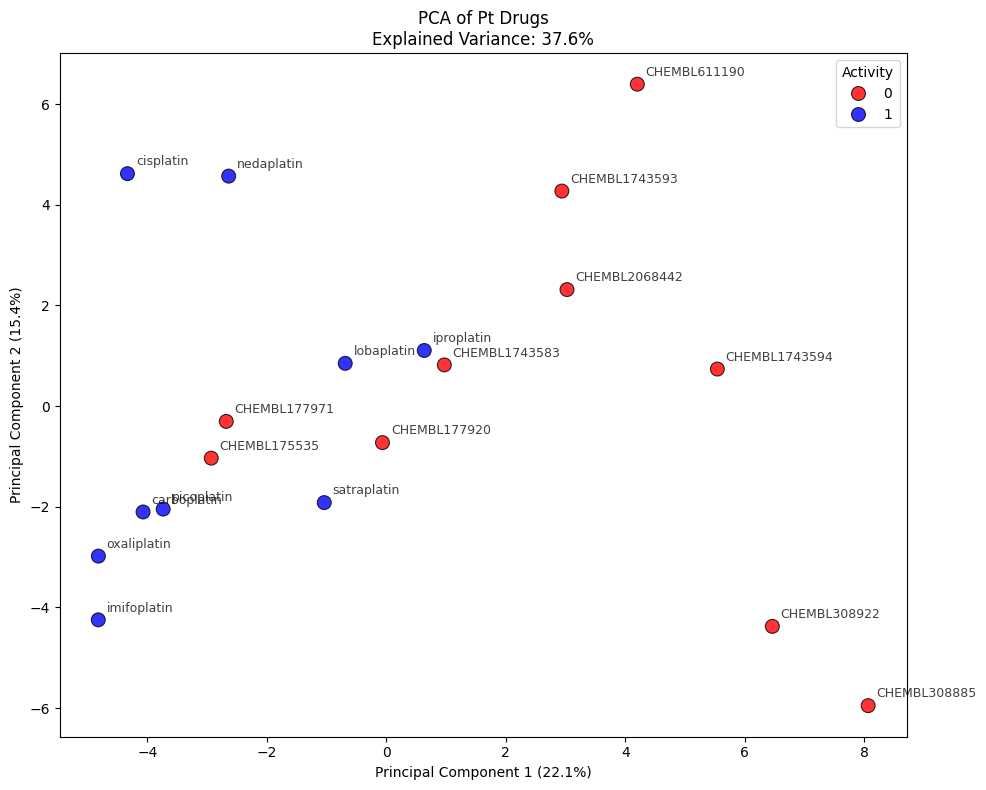

In [5]:
# --- CELL 4 ---
# Standardize features (mean=0, variance=1) - critical for PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Activity'] = y
pca_df['Compound_Name'] = identifiers  # Added compound names to the dataframe

# Plot
plt.figure(figsize=(10, 8))  # Made the figure slightly larger to fit labels
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Activity', 
    data=pca_df, 
    palette=['red', 'blue'], # Adjust colors as needed
    s=100, alpha=0.8, edgecolor='k'
)

# Add labels to each point
for i in range(pca_df.shape[0]):
    plt.annotate(
        pca_df['Compound_Name'].iloc[i], 
        (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]),
        xytext=(6, 6),           # Offsets the text slightly up and right from the dot
        textcoords='offset points',
        fontsize=9,              # Adjust font size if it looks too cluttered
        alpha=0.75               # Slight transparency so they don't block the dots
    )

plt.title(f"PCA of Pt Drugs\nExplained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title='Activity')
plt.tight_layout()
plt.show()

Variance explained by PC1 and PC2: 37.57%


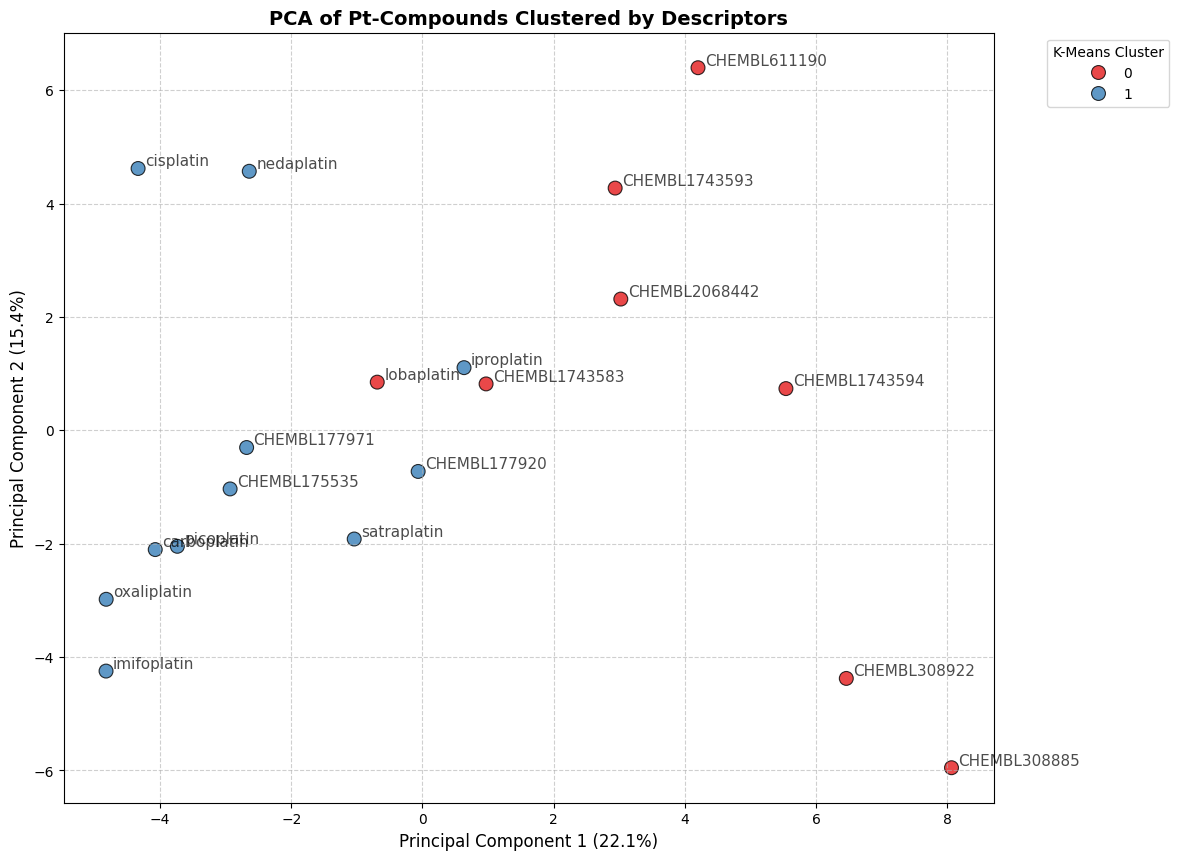

In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- CELL 4: Styled PCA & K-Means Clustering ---

# 1. Scale: Standardization is mandatory
# We use X_clean from Cell 3, which already has variance and correlation filtered
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_clean)

# 2. Dimensionality Reduction: PCA (For Visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create a DataFrame using Compound_Name (identifiers) as the index
df_pca = pd.DataFrame(
    data=pca_result, 
    columns=['PC1', 'PC2'], 
    index=identifiers
)

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"Variance explained by PC1 and PC2: {var_explained:.2f}%")

# 3. Clustering: K-Means
# We fit the clustering algorithm on the FULL scaled dataset
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_pca['Cluster'] = kmeans.fit_predict(scaled_data)

# Make clusters categorical for plotting
df_pca['Cluster'] = df_pca['Cluster'].astype('category')

# 4. Visualization (Using your exact requested style)
plt.figure(figsize=(12, 10))

# Create the scatter plot
ax = sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='Set1', 
    data=df_pca,
    s=100,
    alpha=0.8,
    edgecolor='k'
)

# Loop through the data points to add the Compound_Name labels
for idx, row in df_pca.iterrows():
    plt.annotate(
        idx,                           
        (row['PC1'], row['PC2']),      
        xytext=(5, 2),                 
        textcoords='offset points', 
        fontsize=11,                   
        alpha=0.7                      
    )

plt.title('PCA of Pt-Compounds Clustered by Descriptors', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(title='K-Means Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# (Uncommented tight_layout so the external legend doesn't get clipped in Jupyter)
#plt.tight_layout()
plt.show()

Step 5: Classification Modeling (Leave-One-Out Cross-Validation)

Running Leave-One-Out Cross-Validation. Please wait...

--- Model Performance (LOOCV) ---
Accuracy: 89.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.89      0.89      0.89         9

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19



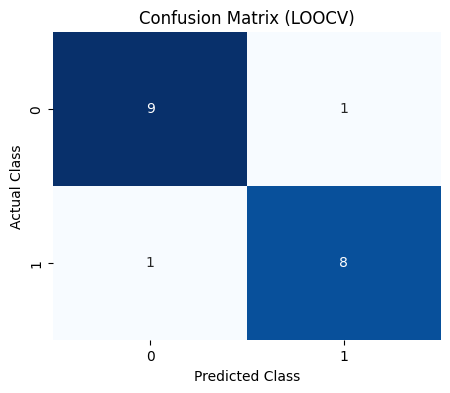

In [7]:
# --- CELL 5 ---
# Initialize the Random Forest Classifier
# We use Random Forest because it handles small, complex datasets well and gives feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Initialize Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Generate cross-validated predictions
print("Running Leave-One-Out Cross-Validation. Please wait...")
y_pred_cv = cross_val_predict(rf_model, X_clean, y, cv=loo)

# Calculate and print metrics
print("\n--- Model Performance (LOOCV) ---")
print(f"Accuracy: {accuracy_score(y, y_pred_cv)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y, y_pred_cv))

# Plot Confusion Matrix
cm = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (LOOCV)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Step 6: Extracting Chemical Intuition (Feature Importance)

/tmp/ipykernel_382105/3886765858.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


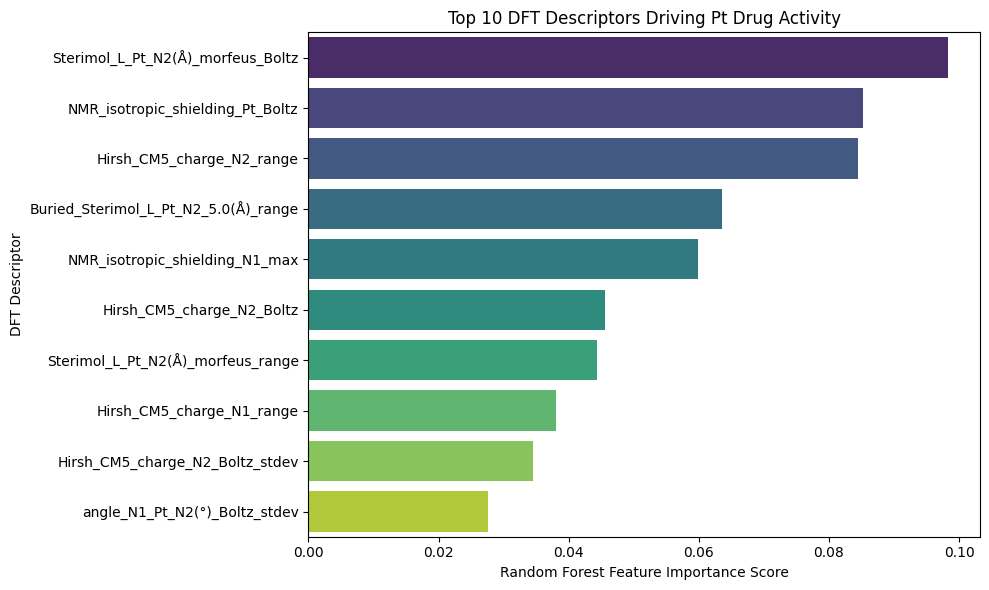

In [8]:
# --- CELL 6 ---
# Train on the full cleaned dataset
rf_model.fit(X_clean, y)

# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame and sort them
importance_df = pd.DataFrame({
    'Descriptor': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important descriptors
top_n = 10
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Descriptor', 
    data=importance_df.head(top_n), 
    palette='viridis'
)
plt.title("Top 10 DFT Descriptors Driving Pt Drug Activity")
plt.xlabel("Random Forest Feature Importance Score")
plt.ylabel("DFT Descriptor")
plt.tight_layout()
plt.show()

Step 7: Model Evaluation Dashboard (CM, ROC, and PR Curves)

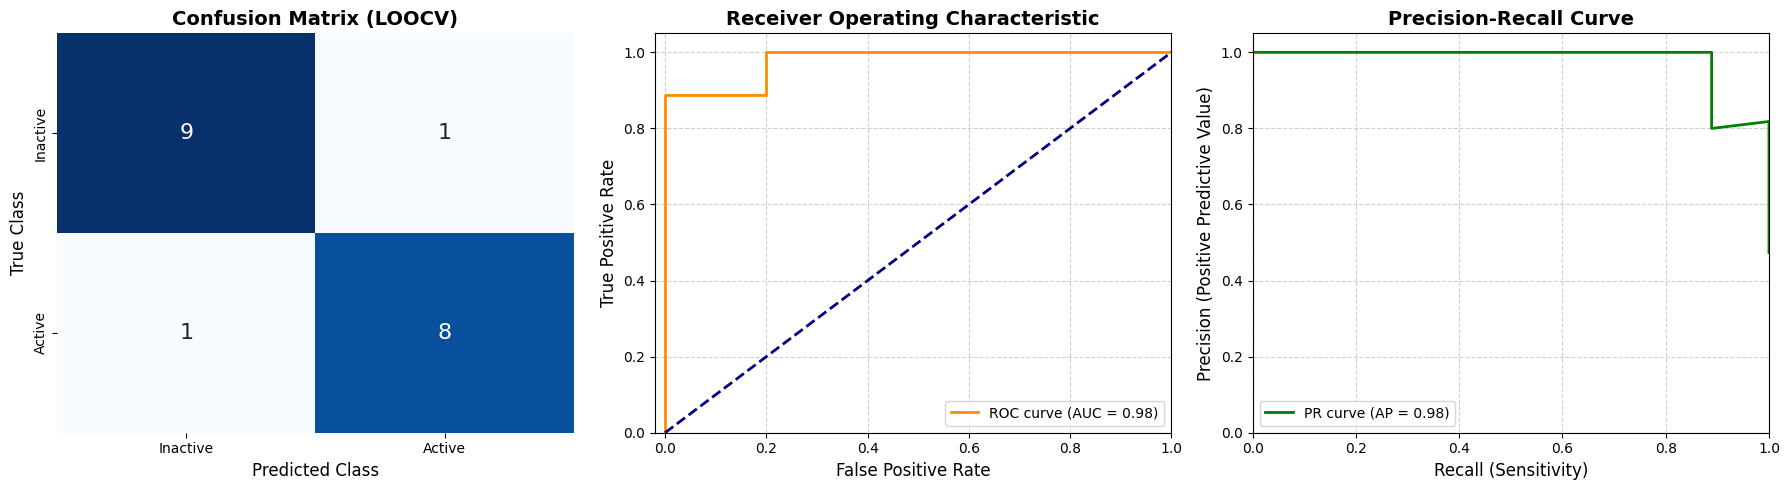

In [9]:
# --- CELL 7: Evaluation Dashboard ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_predict, LeaveOneOut

# 1. Get Probability Predictions using LOOCV
loo = LeaveOneOut()
# We use method='predict_proba' to get the confidence scores for the ROC curve
y_probs_cv = cross_val_predict(rf_model, X_clean, y, cv=loo, method='predict_proba')[:, 1] # Get probabilities for the 'Active' class
y_pred_cv = (y_probs_cv >= 0.5).astype(int) # Convert probabilities back to binary 0/1 predictions

# 2. Calculate Metrics
# ROC Curve metrics
fpr, tpr, thresholds_roc = roc_curve(y, y_probs_cv)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve metrics
precision, recall, thresholds_pr = precision_recall_curve(y, y_probs_cv)
pr_auc = average_precision_score(y, y_probs_cv)

# Confusion Matrix
cm = confusion_matrix(y, y_pred_cv)

# 3. Create the Dashboard (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot A: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'], ax=axes[0],
            annot_kws={"size": 16})
axes[0].set_title('Confusion Matrix (LOOCV)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('True Class', fontsize=12)

# --- Plot B: ROC Curve ---
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Plot C: Precision-Recall Curve ---
axes[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.2f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[2].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower left")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Step 8: Distribution of Top DFT Features

/tmp/ipykernel_382105/1339481422.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_382105/1339481422.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_382105/1339481422.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_382105/1339481422.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


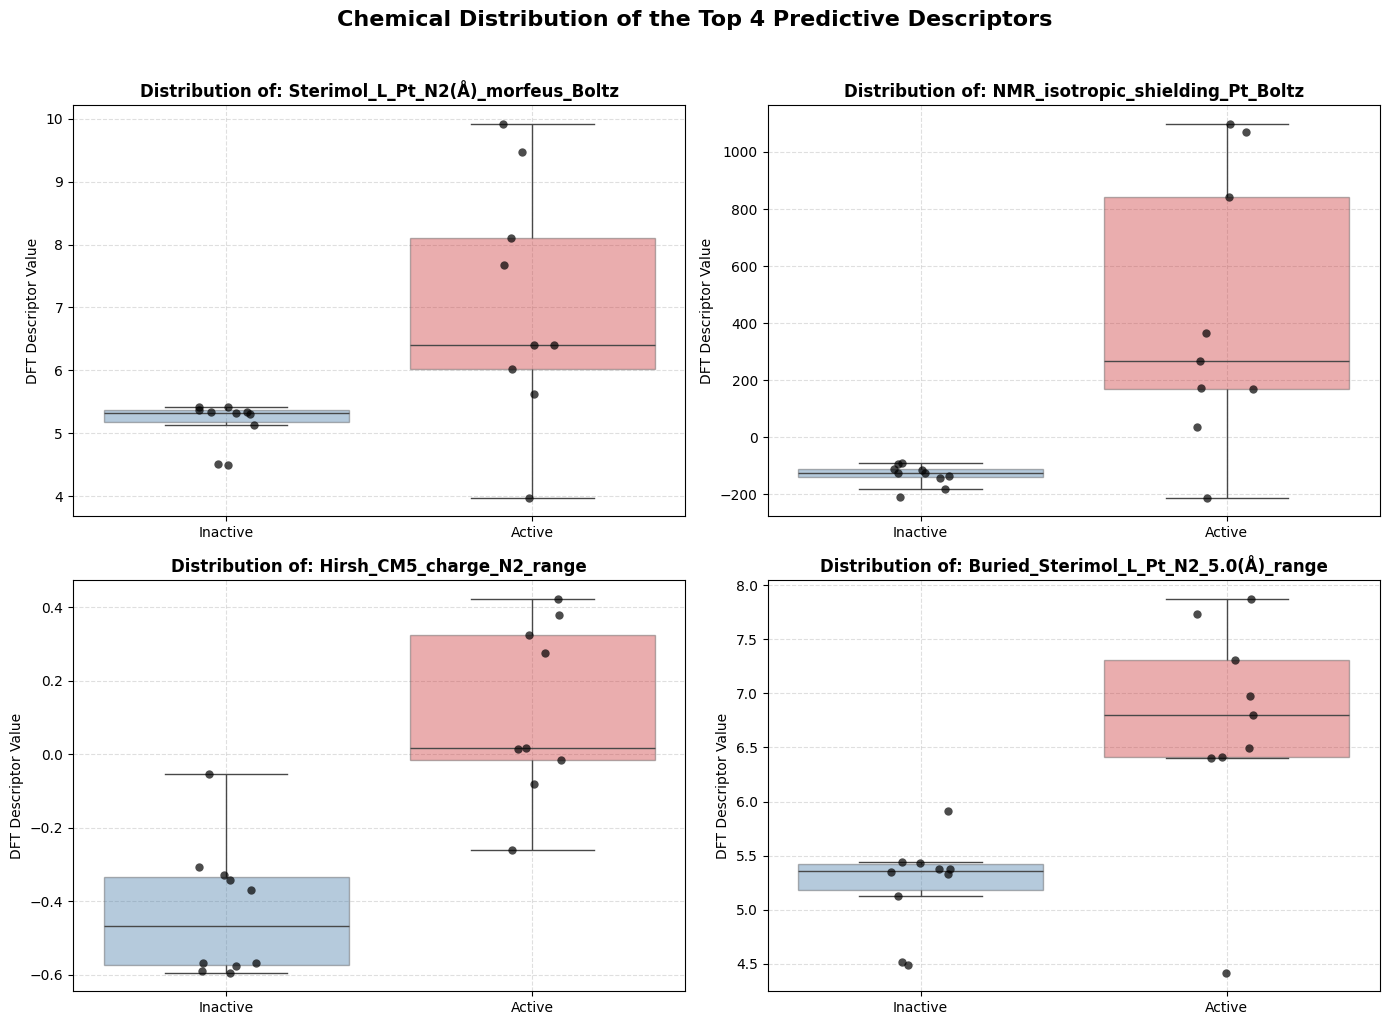

In [10]:
# --- CELL 8: Feature Distributions ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'importance_df' was created in Cell 6. 
# Let's take the top 4 most important features.
top_4_features = importance_df['Descriptor'].head(4).tolist()

# Create a dataframe for plotting that includes the true activity
plot_df = X_clean[top_4_features].copy()
# Map activity 0/1 to clear text labels for the plot
plot_df['Activity_Label'] = ['Active' if val == 1 else 'Inactive' for val in y]

# Set up a 2x2 grid for the 4 features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 matrix to a 1D array for easy looping

# Colors for Inactive (Blue) and Active (Red)
custom_palette = {'Inactive': '#377eb8', 'Active': '#e41a1c'}

# Loop through the top 4 features and plot them
for i, feature in enumerate(top_4_features):
    # Draw the boxplot
    sns.boxplot(
        x='Activity_Label', 
        y=feature, 
        data=plot_df, 
        ax=axes[i],
        palette=custom_palette,
        boxprops=dict(alpha=0.4), # Make boxes transparent so we can see points
        showfliers=False          # Hide boxplot outliers so they don't plot twice with stripplot
    )
    
    # Draw the individual data points on top
    sns.stripplot(
        x='Activity_Label', 
        y=feature, 
        data=plot_df, 
        ax=axes[i],
        color='black',
        alpha=0.7,
        jitter=True, # Spreads points out horizontally so they don't overlap entirely
        size=6
    )
    
    axes[i].set_title(f'Distribution of: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('DFT Descriptor Value')
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Chemical Distribution of the Top 4 Predictive Descriptors', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Calculating true model accuracy...
True Model Accuracy: 89.47%
Running 50 Y-Randomization iterations. Please wait...
  ... Completed 10/50 iterations
  ... Completed 20/50 iterations
  ... Completed 30/50 iterations
  ... Completed 40/50 iterations
  ... Completed 50/50 iterations


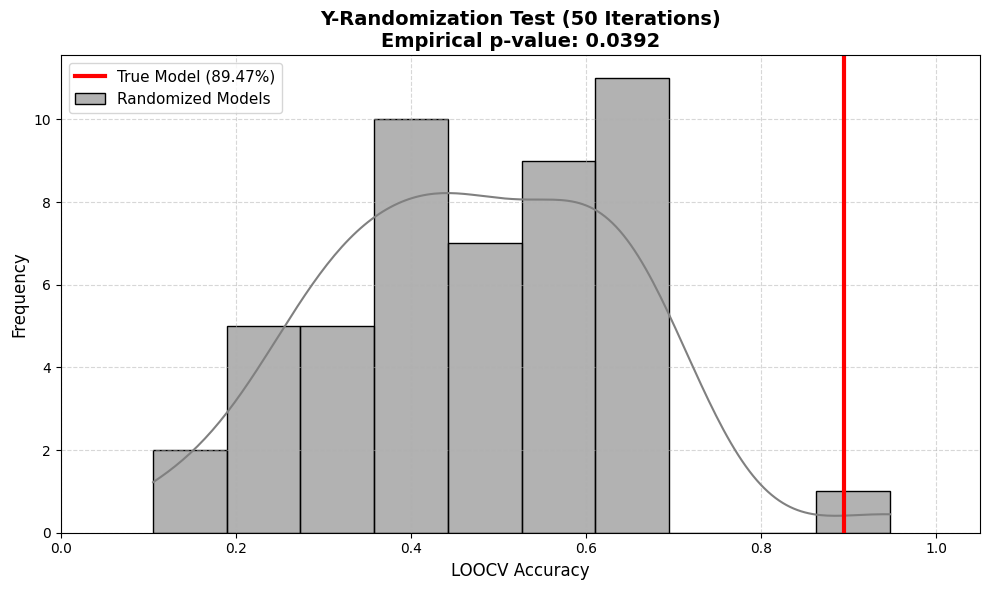


--- Interpretation ---
Average accuracy of randomized models: 47.37%
Conclusion: PASS. Your model is highly statistically significant and is not learning from chance.


In [11]:
# --- CELL 10: Y-Randomization (Sanity Check) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore') # Suppress minor warnings during the loop

# 1. Setup parameters
n_iterations = 50
randomized_accuracies = []
loo = LeaveOneOut()

# Recalculate true accuracy just to be safe
print("Calculating true model accuracy...")
y_pred_true = cross_val_predict(rf_model, X_clean, y, cv=loo)
true_accuracy = accuracy_score(y, y_pred_true)

print(f"True Model Accuracy: {true_accuracy*100:.2f}%")
print(f"Running {n_iterations} Y-Randomization iterations. Please wait...")

# 2. Run the randomization loop
for i in range(n_iterations):
    # Shuffle the target variable randomly
    y_shuffled = np.random.permutation(y)
    
    # Generate predictions for the scrambled dataset
    y_pred_rand = cross_val_predict(rf_model, X_clean, y_shuffled, cv=loo)
    
    # Calculate and store the accuracy
    rand_acc = accuracy_score(y_shuffled, y_pred_rand)
    randomized_accuracies.append(rand_acc)
    
    # Print progress so you know it hasn't frozen
    if (i + 1) % 10 == 0:
        print(f"  ... Completed {i + 1}/{n_iterations} iterations")

# 3. Calculate empirical p-value
# Formula: (Number of scrambled models better than true model + 1) / (Total iterations + 1)
better_models = sum(1 for acc in randomized_accuracies if acc >= true_accuracy)
p_value = (better_models + 1) / (n_iterations + 1)

# 4. Visualization
plt.figure(figsize=(10, 6))

# Plot the distribution of scrambled accuracies
sns.histplot(randomized_accuracies, bins=10, kde=True, color='gray', alpha=0.6, label='Randomized Models')

# Plot the true accuracy as a solid line
plt.axvline(true_accuracy, color='red', linestyle='-', linewidth=3, label=f'True Model ({true_accuracy*100:.2f}%)')

# Add titles and labels
plt.title(f'Y-Randomization Test ({n_iterations} Iterations)\nEmpirical p-value: {p_value:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('LOOCV Accuracy', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Formatting
plt.xlim(0, 1.05) # Keep x-axis from 0 to 100%
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n--- Interpretation ---")
mean_rand = np.mean(randomized_accuracies)
print(f"Average accuracy of randomized models: {mean_rand*100:.2f}%")
if p_value < 0.05:
    print("Conclusion: PASS. Your model is highly statistically significant and is not learning from chance.")
else:
    print("Conclusion: WARNING. Your model might be overfitting to noise.")